Завдання 1. Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу charges за age для некурців (датафрейм non_smoker_df) з допомогою

Методу МНК (з використанням тільки numpy, без scikit learn)

Full-Batch градієнтного спуску з numpy . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.

З scikit-learn.LinearRegression. Тут зверніть увагу, що вхід X має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись X.to_frame() щоб конвертувати колонку в датафрейм.

Для кожного методу

знайдіть і виведіть коефіцієнти моделі
обчисліть прогнози моделі і збережіть в окрему змінну
порахуйте точність прогнозу RMSE
Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані age проти charges в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей? Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [2]:
import pandas as pd
medical_df = pd.read_csv('medical-charges.csv')
non_smoker_df = medical_df[medical_df.smoker == 'no']

1. Метод МНК

In [3]:
import numpy as np

X = non_smoker_df['age'].values
y = non_smoker_df['charges'].values

n = len(X)

x_mean = X.mean()
y_mean = y.mean()

w_mnk = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)
b_mnk = y_mean - w_mnk * x_mean

print(f"w (нахил): {w_mnk:.4f}")
print(f"b (зсув): {b_mnk:.4f}")

y_pred_mnk = w_mnk * X + b_mnk

rmse_mnk = np.sqrt(np.mean((y - y_pred_mnk) ** 2))
print(f"RMSE (МНК): {rmse_mnk:.4f}")

w (нахил): 267.2489
b (зсув): -2091.4206
RMSE (МНК): 4662.5058


2. Full-Batch градієнтного спуску з numpy

lr=0.01: m=nan, b=nan, фінальний RMSE=nan
lr=0.001: m=nan, b=nan, фінальний RMSE=nan
lr=0.0001: m=221.1046, b=-41.9813, фінальний RMSE=4713.2529


C:\Users\user\AppData\Local\Temp\ipykernel_4256\1903389161.py:16: RuntimeWarning: overflow encountered in square
  rmse = np.sqrt(np.mean(error ** 2))
C:\Users\user\AppData\Local\Temp\ipykernel_4256\1903389161.py:19: RuntimeWarning: overflow encountered in dot
  m_gradient = (2/n) * np.dot(error, X[:, 0])
C:\Users\user\AppData\Local\Temp\ipykernel_4256\1903389161.py:22: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


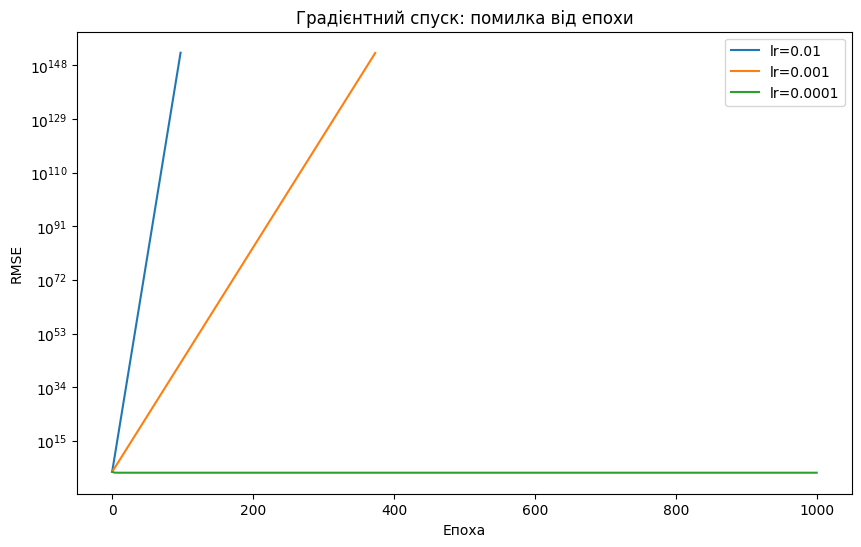

Найкращий learning rate: 0.01
m=nan, b=nan
RMSE: nan


In [15]:
import numpy as np
import matplotlib.pyplot as plt

X = non_smoker_df[['age']].values
y = non_smoker_df['charges'].values

def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0
    n = len(y)
    errors = []
    
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        
        rmse = np.sqrt(np.mean(error ** 2))
        errors.append(rmse)
        
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    
    return m, b, errors

learning_rates = [0.01, 0.001, 0.0001]
results = {}

for lr in learning_rates:
    m, b, errors = full_batch_gradient_descent(X, y, lr=lr, epochs=1000)
    results[lr] = {'m': m, 'b': b, 'errors': errors}
    print(f"lr={lr}: m={m:.4f}, b={b:.4f}, фінальний RMSE={errors[-1]:.4f}")

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    plt.plot(results[lr]['errors'], label=f'lr={lr}')
plt.xlabel('Епоха')
plt.ylabel('RMSE')
plt.title('Градієнтний спуск: помилка від епохи')
plt.legend()
plt.yscale('log')
plt.show()

best_lr = min(learning_rates, key=lambda lr: results[lr]['errors'][-1])
m_gd, b_gd = results[best_lr]['m'], results[best_lr]['b']

print(f"Найкращий learning rate: {best_lr}")
print(f"m={m_gd:.4f}, b={b_gd:.4f}")

predictions_fbgd = m_gd * X[:, 0] + b_gd
rmse_gd = np.sqrt(np.mean((y - predictions_fbgd) ** 2))
print(f"RMSE: {rmse_gd:.4f}")

3. scikit-learn.LinearRegression

In [ ]:
from sklearn.linear_model import LinearRegression

X = non_smoker_df[['age']].values  # X має бути 2D
y = non_smoker_df['charges'].values

lin_reg = LinearRegression()
lin_reg.fit(X, y)

predictions_sklearn = lin_reg.predict(X)

m_sklearn = lin_reg.coef_[0]
b_sklearn = lin_reg.intercept_

print(f"m={m_sklearn:.4f}, b={b_sklearn:.4f}")

rmse_sklearn = np.sqrt(np.mean((y - predictions_sklearn) ** 2))
print(f"RMSE: {rmse_sklearn:.4f}")

w=267.2489, b=-2091.4206, RMSE=4662.5058


Завдання 2. Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для курців за їх віком. Виведіть

Коефіцієнт (m): 305.2376
Зсув (b): 20294.1281
RMSE: 10711.0033


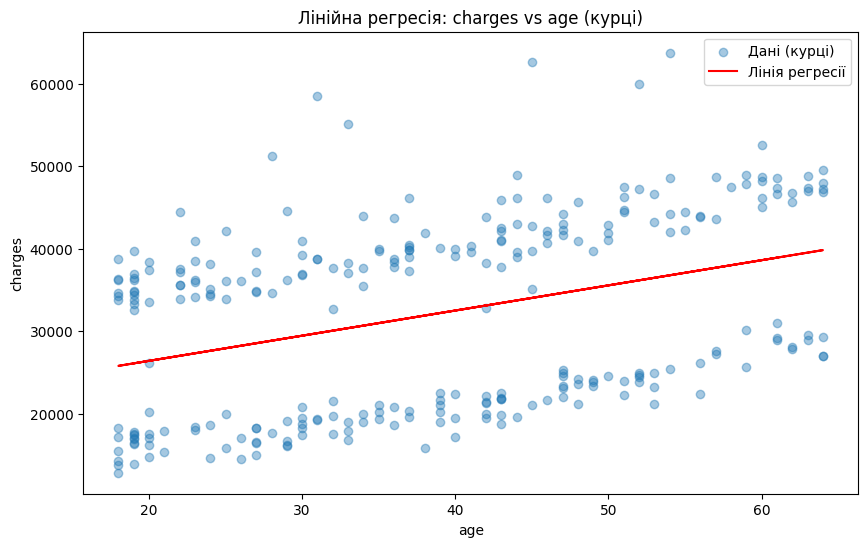

In [19]:
smoker_df = medical_df[medical_df.smoker == 'yes']

X = smoker_df[['age']].values
y = smoker_df['charges'].values

lin_reg_smoker = LinearRegression()
lin_reg_smoker.fit(X, y)

predictions = lin_reg_smoker.predict(X)

m = lin_reg_smoker.coef_[0]
b = lin_reg_smoker.intercept_

print(f"Коефіцієнт (m): {m:.4f}")
print(f"Зсув (b): {b:.4f}")

rmse = np.sqrt(np.mean((y - predictions) ** 2))
print(f"RMSE: {rmse:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.4, label='Дані (курці)')
plt.plot(X, predictions, color='red', label='Лінія регресії')
plt.xlabel('age')
plt.ylabel('charges')
plt.title('Лінійна регресія: charges vs age (курці)')
plt.legend()
plt.show()